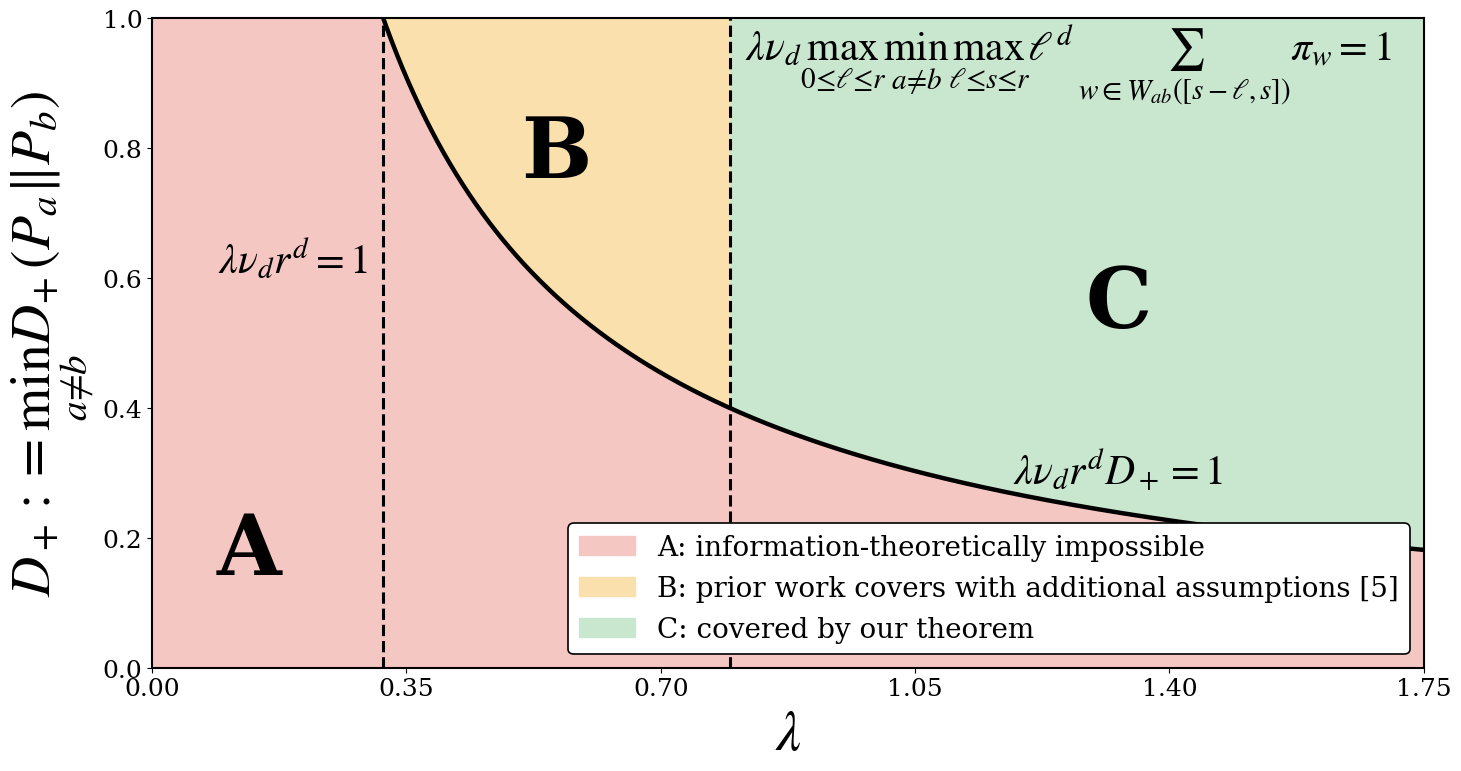

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# --------------------------------------------------
# Parameters
# --------------------------------------------------
d = 2
r = 1.0

connectivity_value = 0.40
Dmax = 1.0

# Volume of the Euclidean unit ball in dimension d
nu_d = np.pi ** (d / 2) / gamma(d / 2 + 1)

lambda_visibility = 1 / (nu_d * r**d)
lambda_connectivity = 1 / (nu_d * connectivity_value)

lambda_max = 2.2 * lambda_connectivity

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "font.family": "serif",
    "mathtext.fontset": "stix",

    "font.size": 18,
    "axes.labelsize": 28,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 1.5,

    "axes.grid": False,

    "xtick.direction": "out",
    "ytick.direction": "out",

    "legend.fontsize": 18,
    "legend.frameon": True,
    "legend.framealpha": 1.0,

    "lines.linewidth": 3.2,

    "savefig.bbox": "tight",
    "savefig.dpi": 300,

    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

# --------------------------------------------------
# Curves
# --------------------------------------------------
lambdas = np.linspace(1e-4, lambda_max, 3500)
info_boundary = 1.0 / (lambdas * nu_d * r**d)

color_A = (0.96, 0.78, 0.76)
color_B = (0.98, 0.88, 0.68)
color_C = (0.79, 0.90, 0.81)


fig, ax = plt.subplots(figsize=(14.5, 7.6),constrained_layout=True,)

# --------------------------------------------------
# Region A
# --------------------------------------------------
ax.fill_between(
    lambdas,
    0,
    np.minimum(info_boundary, Dmax),
    color=color_A,
    label="A: information-theoretically impossible",
)

# --------------------------------------------------
# Region B
# --------------------------------------------------
mask_B = (
    (lambdas >= lambda_visibility)
    & (lambdas <= lambda_connectivity)
    & (info_boundary < Dmax)
)

ax.fill_between(
    lambdas[mask_B],
    info_boundary[mask_B],
    Dmax,
    color=color_B,
    label="B: prior work covers with additional assumptions [5]",
)

# --------------------------------------------------
# Region C
# --------------------------------------------------
mask_C = (
    (lambdas >= lambda_connectivity)
    & (info_boundary < Dmax)
)

ax.fill_between(
    lambdas[mask_C],
    info_boundary[mask_C],
    Dmax,
    color=color_C,
    label="C: covered by our theorem",
)

# --------------------------------------------------
# Main boundaries
# --------------------------------------------------
ax.plot(lambdas,info_boundary,color="black",linewidth=3.2)
ax.axvline(lambda_visibility,color="black",linestyle="--",linewidth=2.2)
ax.axvline(lambda_connectivity,color="black",linestyle="--",linewidth=2.2)

ax.text(0.42 * lambda_visibility,0.18 * Dmax,"A",fontsize=60,fontweight="bold",ha="center",va="center")
ax.text((lambda_visibility + lambda_connectivity) / 2,0.79 * Dmax,"B",fontsize=60,fontweight="bold",ha="center",va="center")
ax.text(0.76 * lambda_max,0.56 * Dmax,"C",fontsize=60,fontweight="bold",ha="center",va="center",)

# --------------------------------------------------
# Threshold labels
# --------------------------------------------------
ax.text(lambda_visibility - 0.13 * lambda_max,0.63 * Dmax, r"$\lambda \nu_d r^d = 1$",fontsize=30,ha="left",va="center")

x_formula = lambda_connectivity + 0.012 * lambda_max
ax.text(
    x_formula,
    0.93 * Dmax,
    (
        r"$\lambda\nu_d"
        r"\max_{0\leq \ell\leq r}"
        r"\min_{a\neq b}"
        r"\max_{\ell \leq s\leq r}"
        r"\ell^d"
        r"\sum_{w\in W_{ab}([s-\ell,s])}"
        r"\pi_w"
        r"=1$"
    ),
    fontsize=30,
    ha="left",
    va="center"
)

lambda_curve = 0.76 * lambda_max
D_curve = 1 / (lambda_curve * nu_d * r**d)

ax.text(lambda_curve,D_curve + 0.03 * Dmax,r"$\lambda\nu_d r^d D_+ = 1$",fontsize=30,ha="center",va="bottom")

ax.set_xlim(0, lambda_max)
ax.set_ylim(0, Dmax)

ax.set_xlabel(r"$\lambda$",fontsize=40)
ax.set_ylabel(r"$D_+ := \min_{a\neq b} D_+(P_a\Vert P_b)$",fontsize=40)

# Numerical ticks
xtick_values = np.linspace(0, lambda_max, 6)
ytick_values = np.linspace(0, Dmax, 6)

ax.set_xticks(xtick_values)
ax.set_yticks(ytick_values)
ax.set_xticklabels([f"{x:.2f}"for x in xtick_values])
ax.set_yticklabels([f"{y:.1f}"for y in ytick_values])

legend = ax.legend(loc="lower right",frameon=True,facecolor="white",edgecolor="black",fontsize=20)

legend.get_frame().set_linewidth(1.2)
plt.show()


In [14]:
fig.savefig("results/phase_diagram.pdf")